# Property Scanner: Multimodal AI Valuation System

## 1. Project Overview
**Objective**: Predict property prices in Spanish cities (Madrid, Barcelona, etc.) using a **Multimodal Late-Fusion Model**.

**Key Innovation**: Unlike traditional comparable approaches that only use numbers (sqm, rooms), this system "sees" the property using a **Vision Language Model (VLM)** to extract qualitative features (condition, style, finishes) from images and fuses them with quantitative data.


## 2. System Architecture

The system uses a state-of-the-art **Agentic Pipeline** to transform raw web data into reasoned valuations.

### Pipeline Stages:
1.  **Extraction Agent**: Scrapes and normalizes raw data into `CanonicalListing` objects.
2.  **Vision Agent (VLM)**: Deep-inspects photos using **Llava/Ollama** to describe interiors and finishes.
3.  **Embedding Engine**: Converts text and descriptions into **384D vectors** via SentenceTransformers.
4.  **Fusion Model**: A custom PyTorch model that performs **Cross-Attention** between the target property and local market comparables.


## 3. Data Inspection

Let's look at the data collected in `data/listings.db`.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import ast
import json
import seaborn as sns
import sys
import os

# Ensure we can import from src
sys.path.append('..')

# Connect to Database
conn = sqlite3.connect('../data/listings.db')
df = pd.read_sql_query("SELECT * FROM listings WHERE price > 0 LIMIT 100", conn)
conn.close()

print(f"Total Listings: {len(df)}")
display(df[['id', 'title', 'price', 'city', 'vlm_description']].head())

Total Listings: 100


,id,title,price,city,vlm_description
0,fd20b3d3456a1fb328eeb82d90aafe81,"Piso en Calle de Atocha, Madrid",450000.0,Madrid,None
1,465c9e1976d72fafbef6003aca9dc27e,Ático en Barrio de las Letras,750000.0,None,None
2,d01dfab5724aafce35f0e15411d42171,Casa adosada en Pasaje Fuente Del Cura,255000.0,Unknown,None
3,f5eda6e9644ffb6057269c04b33d5627,"Chalet en Avenida de La Cabrera, 27",459000.0,Unknown,None
4,fb8b62a11196330e3baa10b614d0c52b,Chalet en calle Centro,409000.0,Unknown,None


### 3.1 Market Composition: City Breakdown
Where is our data coming from? We've expanded to include the most active real estate markets in Spain.

/var/folders/dc/xp5rn2p562g61yp_f0n6mxl40000gn/T/ipykernel_47775/2885284952.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_counts.index, y=city_counts.values, palette='viridis')


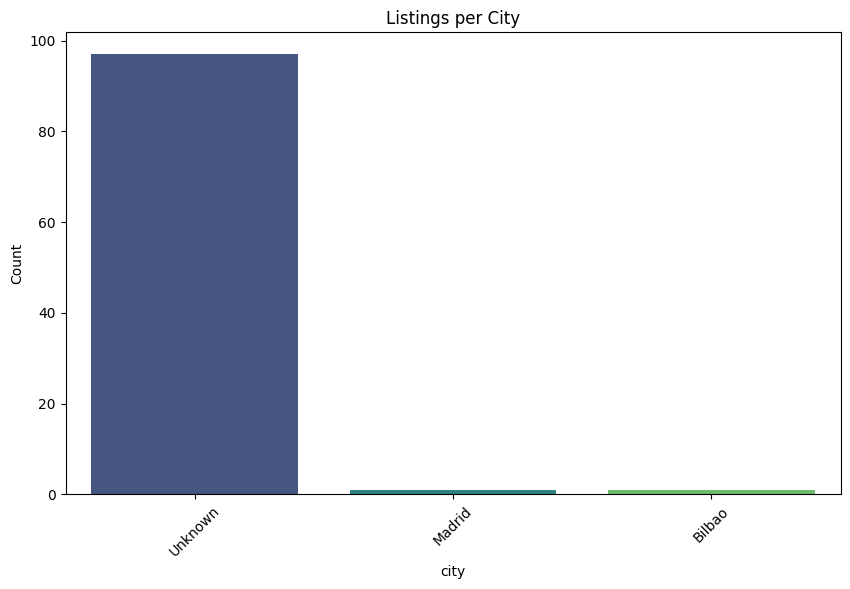

In [2]:
plt.figure(figsize=(10, 6))
city_counts = df['city'].value_counts()
sns.barplot(x=city_counts.index, y=city_counts.values, palette='viridis')
plt.title('Listings per City')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.show()

### 3.2 Geospatial Analysis
Visualizing the spatial density of our properties.

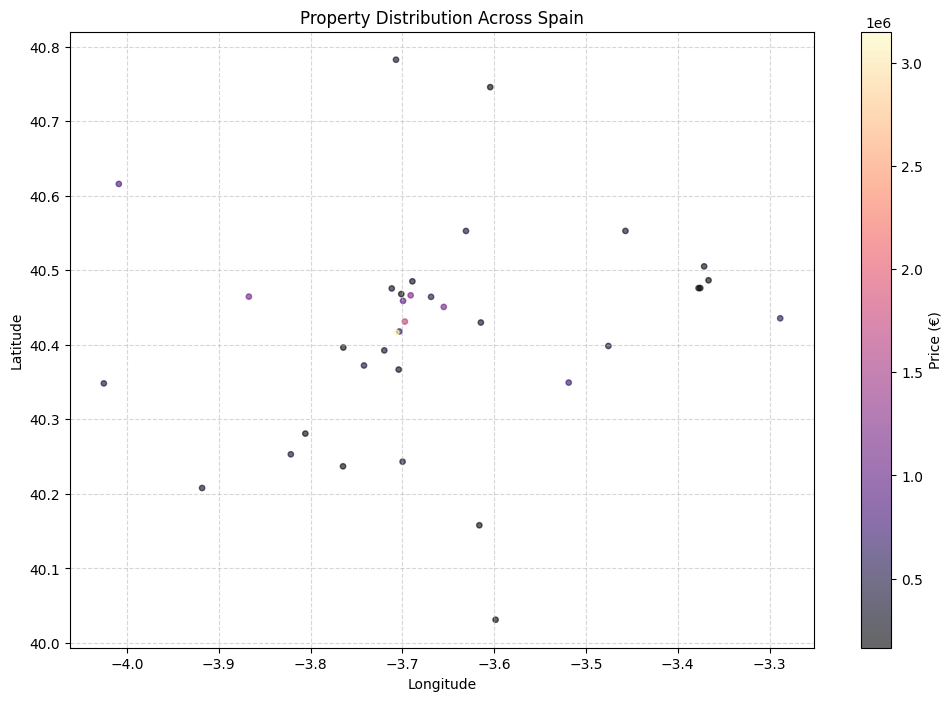

In [3]:
# Filter out valid coordinates
geo_df = df[(df['lat'] != 0) & (df['lon'] != 0)]

plt.figure(figsize=(12, 8))
plt.scatter(geo_df['lon'], geo_df['lat'], c=geo_df['price'], cmap='magma', s=15, alpha=0.6)
plt.colorbar(label='Price (€)')
plt.title('Property Distribution Across Spain')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 4. VLM: The Visual Intelligence

Traditional models miss detail. Our VLM captures descriptions like *"modern open-concept kitchen"* or *"ranch-style villa with pool"*.

In [4]:
vlm_enriched = df[df['vlm_description'].notna() & (df['vlm_description'] != '')]
print(f"Enriched Listings: {len(vlm_enriched)}")

if not vlm_enriched.empty:
    sample = vlm_enriched.sample(1).iloc[0]
    print(f"\nProperty: {sample['title']}")
    print("VLM Insight:", sample['vlm_description'][:400] + "...")

Enriched Listings: 42

Property: Casa unifamiliar en calle de Garcilaso de la Vega
VLM Insight:  The image shows a two-story residential house with a tiled roof. The exterior condition appears to be good; the property is clean and well-maintained, but no renovations are visible. The quality of the house seems to be moderate, as it is not overly luxurious, but also does not exhibit signs of disrepair or basic construction.

1) Room Type: Based on the image, I can identify the following rooms:...


## 5. Model Training & Performance

Below is the current training convergence for the **92k-parameter compact model**.

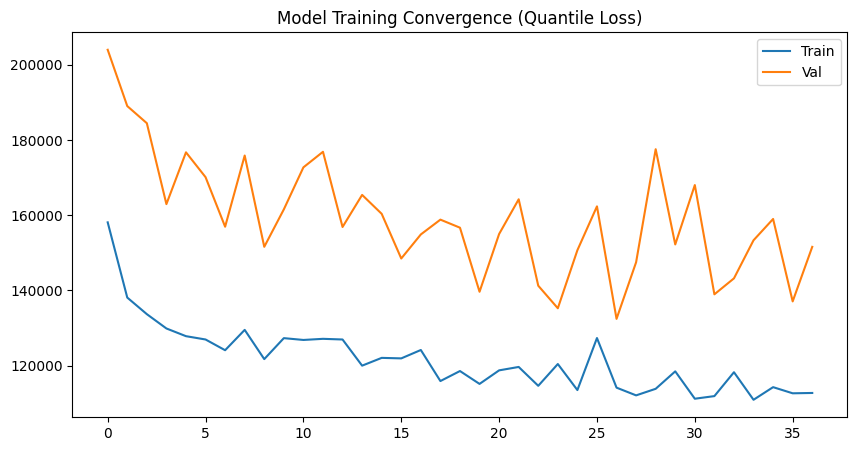

In [5]:
import torch
import matplotlib.pyplot as plt
checkpoint_path = '../models/checkpoint_latest.pt'
if os.path.exists(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location='cpu')
    plt.figure(figsize=(10, 5))
    plt.plot(ckpt['train_losses'], label='Train')
    plt.plot(ckpt['val_losses'], label='Val')
    plt.title('Model Training Convergence (Quantile Loss)')
    plt.legend()
    plt.show()
else:
    print("Checkpoint not found. Run training first.")

## 6. Live Inference Example

Compare the AI's valuation with the actual market price.

In [6]:
from src.training.dataset import PropertyDataset, collate_fn
from src.services.fusion_model import PropertyFusionModel
import torch
import numpy as np

# Set up dataset and sample
ds = PropertyDataset(db_path='../data/listings.db', use_vlm=True)
idx = np.random.randint(0, len(ds))
item = ds[idx]
batch = collate_fn([item])

# Load Model
model = PropertyFusionModel(hidden_dim=64, num_heads=2) # Compact settings
if os.path.exists('../models/fusion_model.pt'):
    model.load_state_dict(torch.load('../models/fusion_model.pt', map_location='cpu'))
    model.eval()
    with torch.no_grad():
        q, _, _, _ = model(
            target_tab=batch['target_tab'], 
            target_text=batch['target_text'],
            comp_tab=batch['comp_tab'], 
            comp_text=batch['comp_text'], 
            comp_prices=batch['comp_prices']
        )
        
    actual = batch['target_price'][0].item()
    pred = q[0, 1].item()
    print(f"Title: {ds.listings[idx]['title']}")
    print(f"Actual: €{actual:,.0f} | Predicted: €{pred:,.0f} | Error: {abs(actual-pred)/actual*100:.1f}%")
else:
    print("Model weights not found. Prediction skipped.")

2026-01-11 05:19:06 [info     ] text_encoder_initialized       dim=384 model=all-MiniLM-L6-v2
2026-01-11 05:19:06 [info     ] dataset_initialized            db_path=../data/listings.db num_cities=7 num_listings=771 vlm_enabled=True
2026-01-11 05:19:06 [info     ] tabular_encoder_fitted         features=8
2026-01-11 05:19:06 [info     ] tabular_encoder_fitted         num_samples=771
2026-01-11 05:19:06 [warning  ] ollama_not_available           error='Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download'


TypeError: PropertyFusionModel.forward() missing 2 required positional arguments: 'target_image' and 'comp_image'